In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## # Load datasets

In [2]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

## # BASIC INFO

In [3]:
print("Matches Data:")
print(matches.head())
print(matches.info())

print("\nDeliveries Data:")
print(deliveries.head())
print(deliveries.info())

Matches Data:
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0

## # ANALYSIS 1: Matches Won by Team

In [4]:
wins = matches['winner'].value_counts()
print("\nMost Matches Won:")
print(wins)


Most Matches Won:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


## # ANALYSIS 2: Top Batsmen (Most Runs)

In [5]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print("\nTop Batsmen:")
print(top_batsmen)


Top Batsmen:
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


## # ANALYSIS 3: Top Bowlers (Wickets)

In [6]:
wickets = deliveries[deliveries['dismissal_kind'].notna()]
top_bowlers = wickets['bowler'].value_counts().head(10)
print("\nTop Bowlers:")
print(top_bowlers)


Top Bowlers:
bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: count, dtype: int64


## # ANALYSIS 4: Toss Winners

In [7]:
toss = matches['toss_winner'].value_counts()
print("\nToss Winners:")
print(toss)


Toss Winners:
toss_winner
Mumbai Indians                 143
Kolkata Knight Riders          122
Chennai Super Kings            122
Rajasthan Royals               120
Royal Challengers Bangalore    113
Sunrisers Hyderabad             88
Kings XI Punjab                 85
Delhi Daredevils                80
Delhi Capitals                  50
Deccan Chargers                 43
Punjab Kings                    24
Gujarat Titans                  22
Pune Warriors                   20
Lucknow Super Giants            19
Gujarat Lions                   15
Kochi Tuskers Kerala             8
Royal Challengers Bengaluru      8
Rising Pune Supergiants          7
Rising Pune Supergiant           6
Name: count, dtype: int64


## # MERGING DATASETS

In [10]:
merged = pd.merge(
    deliveries,
    matches,
    left_on='match_id',
    right_on='id',
    how='inner'
)

## # EXTRA INSIGHT: Top Run Scorers After Merge

In [11]:
top_runs = merged.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print("\nTop Run Scorers (Merged):")
print(top_runs)


Top Run Scorers (Merged):
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


## # SAVE OUTPUT

In [12]:
top_runs.to_csv("top_players.csv")

## # VISUALIZATION

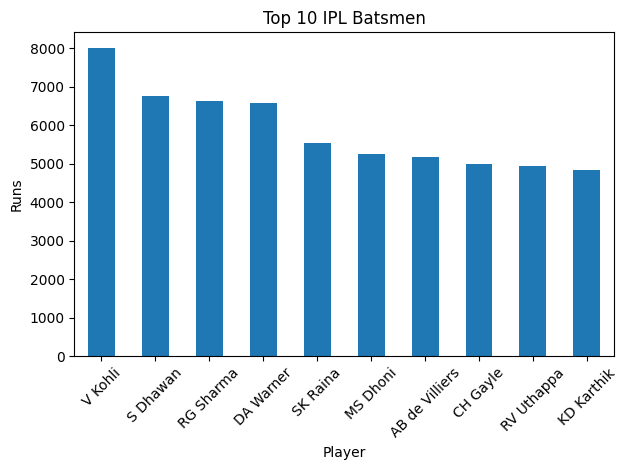

In [13]:
top_runs.plot(kind='bar')
plt.title("Top 10 IPL Batsmen")
plt.xlabel("Player")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## # Balls faced (exclude wides)

In [14]:
balls = deliveries[deliveries['extras_type'] != 'wides']

batsman_stats = balls.groupby('batter').agg({
    'batsman_runs': 'sum',
    'ball': 'count'
}).rename(columns={'ball': 'balls_faced'})

batsman_stats['strike_rate'] = (batsman_stats['batsman_runs'] / batsman_stats['balls_faced']) * 100

# Top 10 by strike rate (min 200 balls filter for accuracy)
top_sr = batsman_stats[batsman_stats['balls_faced'] > 200].sort_values(by='strike_rate', ascending=False).head(10)

print("\nTop Batsmen by Strike Rate:")
print(top_sr)


Top Batsmen by Strike Rate:
                batsman_runs  balls_faced  strike_rate
batter                                                
PD Salt                  653          372   175.537634
AD Russell              2488         1423   174.841883
TM Head                  772          444   173.873874
T Stubbs                 405          233   173.819742
TH David                 659          387   170.284238
H Klaasen                993          590   168.305085
SP Narine               1534          925   165.837838
LS Livingstone           939          578   162.456747
N Pooran                1769         1092   161.996337
Rashid Khan              545          337   161.721068


## # Total runs conceded (including extras)

In [15]:
bowler_runs = deliveries.groupby('bowler')['total_runs'].sum()

# Balls bowled (excluding wides & no balls)
legal_balls = deliveries[(deliveries['extras_type'] != 'wides') & (deliveries['extras_type'] != 'noballs')]
balls_bowled = legal_balls.groupby('bowler')['ball'].count()

bowler_stats = pd.concat([bowler_runs, balls_bowled], axis=1)
bowler_stats.columns = ['runs_conceded', 'balls_bowled']

# Convert balls to overs
bowler_stats['overs'] = bowler_stats['balls_bowled'] / 6

bowler_stats['economy'] = bowler_stats['runs_conceded'] / bowler_stats['overs']

# Top economical bowlers (min 50 overs)
top_economy = bowler_stats[bowler_stats['overs'] > 50].sort_values(by='economy').head(10)

print("\nTop Bowlers by Economy:")
print(top_economy)


Top Bowlers by Economy:
                  runs_conceded  balls_bowled       overs   economy
bowler                                                             
A Kumble                   1089           965  160.833333  6.770984
GD McGrath                  366           324   54.000000  6.777778
SP Narine                  4672          4081  680.166667  6.868905
J Yadav                     447           390   65.000000  6.876923
DL Vettori                  894           777  129.500000  6.903475
M Muralitharan             1765          1528  254.666667  6.930628
RE van der Merwe            515           443   73.833333  6.975169
Rashid Khan                3340          2872  478.666667  6.977716
MJ Santner                  428           366   61.000000  7.016393
J Botha                     818           694  115.666667  7.072046


## Strike Rate Chart

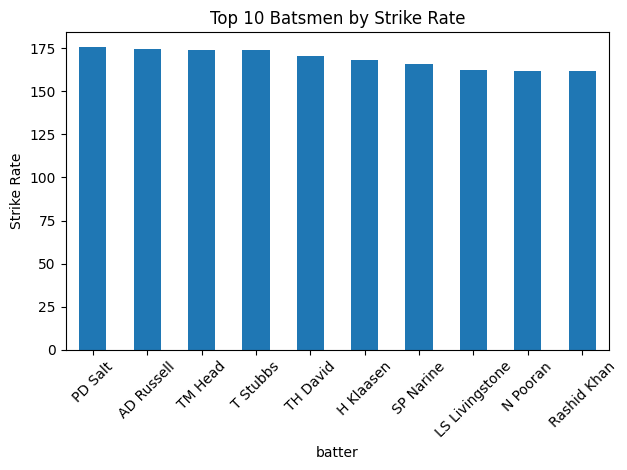

In [16]:
top_sr['strike_rate'].plot(kind='bar')
plt.title("Top 10 Batsmen by Strike Rate")
plt.ylabel("Strike Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Economy Chart

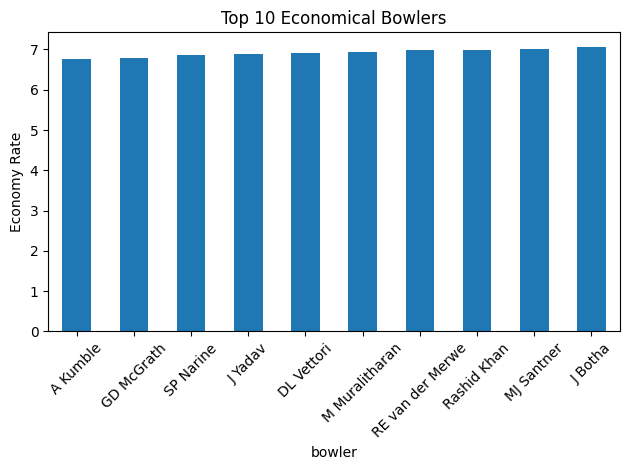

In [17]:
top_economy['economy'].plot(kind='bar')
plt.title("Top 10 Economical Bowlers")
plt.ylabel("Economy Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
top_sr.to_csv("top_strike_rate.csv")
top_economy.to_csv("top_economy.csv")